# El modelo X-13 de BCR: cómo funciona y réplica

**Proyecto BCR · Lab 2 · Épica E4 (SCRUM-23)**

BCR estima la producción de biocombustibles con **X-13ARIMA-SEATS**, un
programa libre del Census de EE.UU. No es un modelo propio: es una
herramienta estándar que usan institutos de estadística de todo el mundo
(INDEC incluido). Acá lo replicamos para tener el **número exacto a superar**.

## ¿Qué hace X-13 por dentro?

Trabaja en dos grandes etapas:

1. **regARIMA (la parte de pronóstico).** Ajusta a la serie un modelo
   **SARIMA** (ARIMA con componente estacional) y, de paso, puede corregir
   outliers y efectos de calendario. Elige el modelo **automáticamente**
   (procedimiento `automdl`). Con ese modelo, **extiende la serie** hacia
   adelante: ese es el pronóstico del mes que falta.

2. **Ajuste estacional (X-11).** Descompone la serie en tres partes:
   **tendencia-ciclo** + **estacionalidad** + **irregular**. Al sacarle la
   estacionalidad, queda la serie "desestacionalizada", que es la que BCR
   publica como variación mensual en el IACA.

El `pip install x13binary` trae el motor; no hace falta instalar nada más.

In [1]:
# Requisitos: pip install x13binary statsmodels pandas numpy matplotlib
import subprocess, tempfile
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from x13binary import find_x13_bin

X13 = find_x13_bin()
plt.rcParams["figure.figsize"] = (12, 4)
print("Binario X-13:", X13)

Binario X-13: c:\Users\juanc\AppData\Local\Programs\Python\Python313\Scripts\x13as_html.exe


## 1. Correr X-13 sobre la producción de biodiesel

Le pasamos la serie cruda y le pedimos: transformación logarítmica (como
usa BCR para biodiesel), selección automática del modelo, descomposición
(`x11`) y un pronóstico a un mes. Guardamos las tablas de componentes para
graficarlas.

In [2]:
def correr_x13(serie, log=True):
    """Corre X-13 y devuelve (texto_salida, componentes, pronóstico).

    componentes: DataFrame con seasonal (d10), seasadj (d11),
    trend (d12), irregular (d13). pronóstico: valor a un mes.
    """
    vals = serie.values
    start = f"{serie.index[0].year}.{serie.index[0].month}"
    chunks = [vals[i:i+10] for i in range(0, len(vals), 10)]
    datalines = "\n".join("    " + " ".join(f"{v:.3f}" for v in c) for c in chunks)
    tr = "log" if log else "none"
    spec = (
        f"series{{\n start={start}\n period=12\n data=(\n{datalines}\n )\n}}\n"
        f"transform{{ function={tr} }}\n"
        "automdl{}\n"
        "x11{ save=(d10 d11 d12 d13) }\n"
        "forecast{ maxlead=1 save=(fct) }\n"
    )
    tmp = Path(tempfile.mkdtemp()); base = tmp / "r"
    base.with_suffix(".spc").write_text(spec)
    subprocess.run([X13, str(base)], cwd=tmp, capture_output=True, text=True, timeout=60)

    import re
    texto = re.sub("<[^>]*>", "", (base.with_suffix(".html")).read_text(encoding="latin-1"))

    def leer_tabla(ext):
        p = base.with_suffix(ext)
        if not p.exists():
            return None
        df = pd.read_csv(p, sep="\t", skiprows=2, names=["date", ext[1:]])
        df["date"] = pd.to_datetime(df["date"].astype(int).astype(str), format="%Y%m")
        return df.set_index("date")[ext[1:]]

    comp = pd.concat([leer_tabla(e) for e in [".d10", ".d11", ".d12", ".d13"]], axis=1)
    comp.columns = ["estacional", "desestacionalizada", "tendencia", "irregular"]

    fct = base.with_suffix(".fct")
    pron = np.nan
    if fct.exists():
        linea = [l for l in fct.read_text().splitlines() if l and l[0].isdigit()][-1]
        pron = float(linea.split("\t")[1].replace("E", "e"))
    return texto, comp, pron


bd = (pd.read_csv("../data/produccion_biodiesel.csv", parse_dates=["fecha"])
        .sort_values("fecha").set_index("fecha"))
serie = bd["produccion_tn"]

texto, comp, pron = correr_x13(serie, log=True)
print(f"Pronóstico X-13 para el mes siguiente: {pron:,.0f} toneladas")

Pronóstico X-13 para el mes siguiente: 121,018 toneladas


### El modelo que eligió

X-13 probó varios SARIMA y se quedó con el que mejor ajusta. Lo informa en
su salida:

In [3]:
import re
for linea in texto.split("\n"):
    if re.search(r"\(\d \d \d\)\(\d \d \d\)", linea):
        print("Modelo elegido:", linea.strip())
        break

Modelo elegido: Preliminary model choice : (2 0 2)(1 0 1)


### La descomposición

Así separa X-13 la serie: la producción observada, la tendencia de fondo, el
patrón estacional que se repite cada año, y lo irregular (lo que no explica
ni tendencia ni estacionalidad).

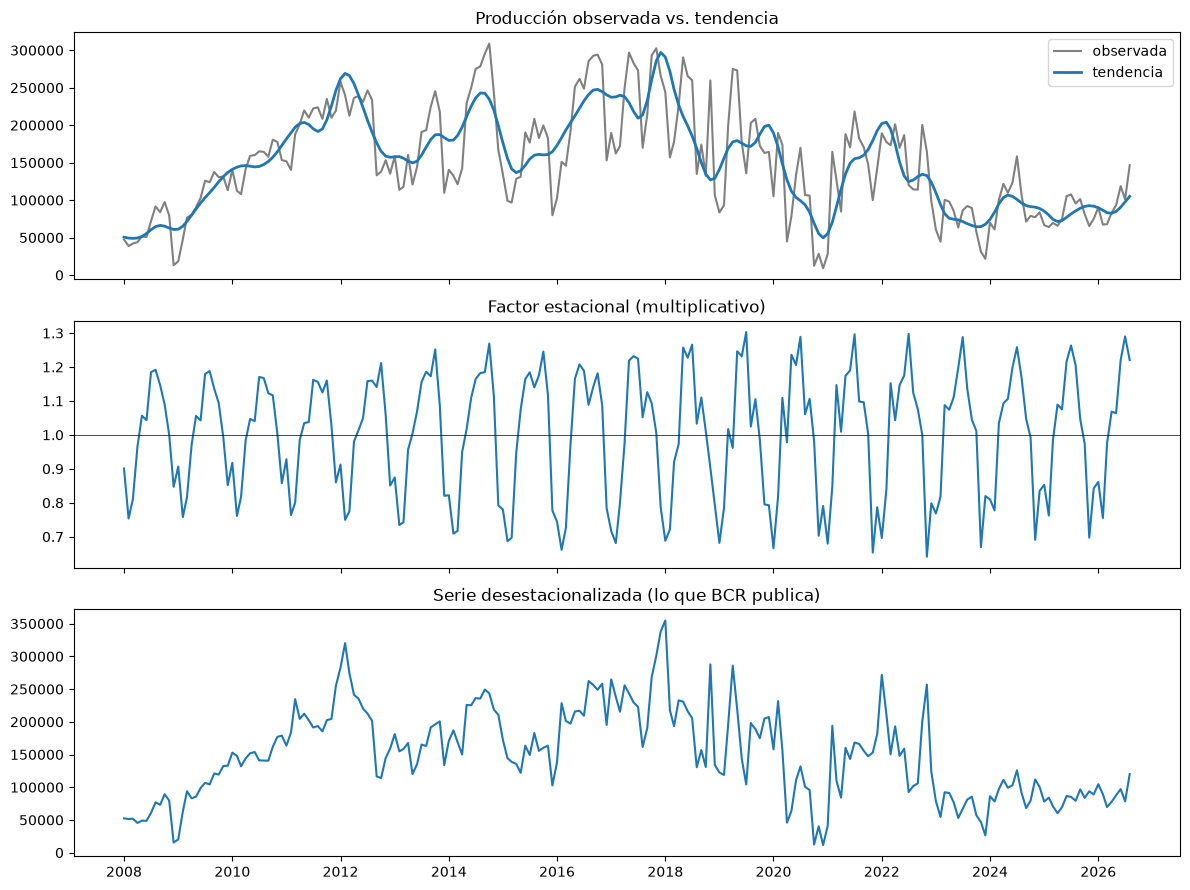

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
axes[0].plot(serie.index, serie.values, label="observada", color="gray")
axes[0].plot(comp.index, comp["tendencia"], label="tendencia", lw=2)
axes[0].set_title("Producción observada vs. tendencia"); axes[0].legend()
axes[1].plot(comp.index, comp["estacional"]); axes[1].axhline(1, color="k", lw=0.5)
axes[1].set_title("Factor estacional (multiplicativo)")
axes[2].plot(comp.index, comp["desestacionalizada"])
axes[2].set_title("Serie desestacionalizada (lo que BCR publica)")
plt.tight_layout(); plt.show()

## 2. Réplica walk-forward: ¿qué tan bien estima?

Corrimos X-13 mes a mes (cada mes se reentrena con los datos anteriores y
predice el siguiente), sobre las cuatro series, y lo comparamos contra los
baselines con el mismo protocolo. El cálculo completo está en
`scripts/replica_x13.py`; acá cargamos los resultados.

> Correr el walk-forward de X-13 tarda un par de minutos (muchas corridas),
> por eso se deja precalculado en `results/`.

In [8]:
comp_df = pd.read_csv("../results/comparacion.csv")
tabla_mape = comp_df.pivot_table(index="serie", columns="modelo", values="mape").round(1)
tabla_signo = comp_df.pivot_table(index="serie", columns="modelo", values="acierto_signo").round(0)
print("MAPE por serie y modelo (menor = mejor):")
print(tabla_mape.to_string())
print("\nAcierto de signo (mayor = mejor):")
print(tabla_signo.to_string())

MAPE por serie y modelo (menor = mejor):
modelo           naive  naive_estacional   x13
serie                                         
biodiesel         18.2              15.8  13.1
bioetanol_cana    28.4              15.5  16.3
bioetanol_maiz     6.6               6.6   5.9
bioetanol_total   10.3               5.0   7.4

Acierto de signo (mayor = mejor):
modelo           naive  naive_estacional   x13
serie                                         
biodiesel          0.0              64.0  82.0
bioetanol_cana     0.0              91.0  91.0
bioetanol_maiz     0.0              55.0  55.0
bioetanol_total    0.0              64.0  64.0


## 3. Conclusiones

1. **X-13 no siempre gana.** Para el **bioetanol total** y la **caña**, un
   modelo tan simple como el *naive estacional* (mismo mes del año anterior)
   le empata o le gana en MAPE. Eso muestra que **hay lugar para mejorar**:
   la herramienta estándar no está exprimiendo toda la información.
2. Donde X-13 sí es el mejor de los tres es en **biodiesel** y **bioetanol
   de maíz**, pero por poco margen.
3. **El acierto de signo** (si sube o baja) de X-13 es bueno en biodiesel
   (82%) y caña (91%), parejo con el naive estacional en el resto.

**Benchmark a superar por serie** (el mejor entre X-13 y los baselines):

| Serie | Mejor actual | MAPE |
|---|---|---|
| Biodiesel | X-13 | ~13% |
| Bioetanol total | naive estacional | ~5% |
| Bioetanol maíz | X-13 | ~6% |
| Bioetanol caña | naive estacional | ~15-16% |

Nuestros modelos (SARIMAX, ML, LSTM) tienen que mejorar **el mejor de cada
fila**, no solo a X-13.

> Nota: esto es X-13 en modo automático. El de BCR puede tener una
> configuración propia (su archivo `.spc`), que pedimos para una réplica
> exacta. Pero como referencia del método, alcanza.